# 02 — Feature Engineering

Constructing the predictors used in the forecasting models. Each feature is grounded in how rates actually behave — the goal is intuition over complexity.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

df = pd.read_csv('../data/model_features_daily.csv', parse_dates=['date'], index_col='date')
print(df.shape)

(826, 33)


## Feature Groups

**Lagged rates** — rates are highly persistent. Yesterday's rate is the single strongest predictor of today's.

**Curve spreads** — the shape of the curve (slope, inversion depth) carries information about where rates are heading.

**Rolling momentum** — a rate trending over 5 or 20 days is more likely to keep moving in that direction than to reverse.

**Macro context** — VIX captures market stress; credit spreads reflect risk appetite; both move in tandem with rate volatility.

In [6]:
feat = pd.DataFrame(index=df.index)

# --- Lagged rates (yesterday's values) ---
for col in ['fred_sofr', '2_yr', '10_yr', 'fred_dff']:
    feat[f'{col}_lag1'] = df[col].shift(1)
    feat[f'{col}_lag5'] = df[col].shift(5)

# --- Curve spreads ---
feat['slope_10y_2y']  = df['10_yr'] - df['2_yr']       # classic slope
feat['slope_2y_sofr'] = df['2_yr']  - df['fred_sofr']   # front-end vs overnight
feat['slope_10y_3m']  = df['10_yr'] - df['3_mo']        # long vs short

# --- Rolling momentum (5-day and 20-day) ---
for col in ['fred_sofr', '2_yr', '10_yr']:
    feat[f'{col}_roll5']  = df[col].rolling(5).mean()
    feat[f'{col}_roll20'] = df[col].rolling(20).mean()
    feat[f'{col}_vol20']  = df[col].rolling(20).std()   # volatility regime

# --- Macro context ---
feat['vix']     = df['fred_vix']
feat['hy_oas']  = df['fred_hy_oas']
feat['wti']     = df['fred_wti']

print(f"Features built: {feat.shape[1]} columns, {feat.dropna().shape[0]} complete rows")
feat.dropna().tail(3)

Features built: 23 columns, 749 complete rows


,fred_sofr_lag1,fred_sofr_lag5,2_yr_lag1,2_yr_lag5,10_yr_lag1,10_yr_lag5,fred_dff_lag1,fred_dff_lag5,slope_10y_2y,slope_2y_sofr,...,fred_sofr_vol20,2_yr_roll5,2_yr_roll20,2_yr_vol20,10_yr_roll5,10_yr_roll20,10_yr_vol20,vix,hy_oas,wti
date,,,,,,,,,,,,,,,,,,,,,
2026-04-20,3.65,3.63,3.71,3.78,4.26,4.30,3.64,3.64,0.54,0.09,...,0.032163,3.746,3.8085,0.058604,4.278,4.3235,0.049234,18.87,2.87,91.06
2026-04-21,3.63,3.66,3.72,3.76,4.26,4.26,3.64,3.64,0.52,0.15,...,0.032163,3.750,3.8025,0.054760,4.286,4.3190,0.046893,19.50,2.85,91.06
2026-04-22,3.63,3.72,3.78,3.76,4.30,4.29,3.64,3.64,0.51,0.15,...,0.032163,3.756,3.8000,0.054095,4.288,4.3175,0.047002,18.92,2.84,91.06


## Correlation with Target Rates

Which features move most closely with SOFR, 2Y, and 10Y? High correlation doesn't guarantee predictive power — but features with near-zero correlation aren't carrying useful signal.

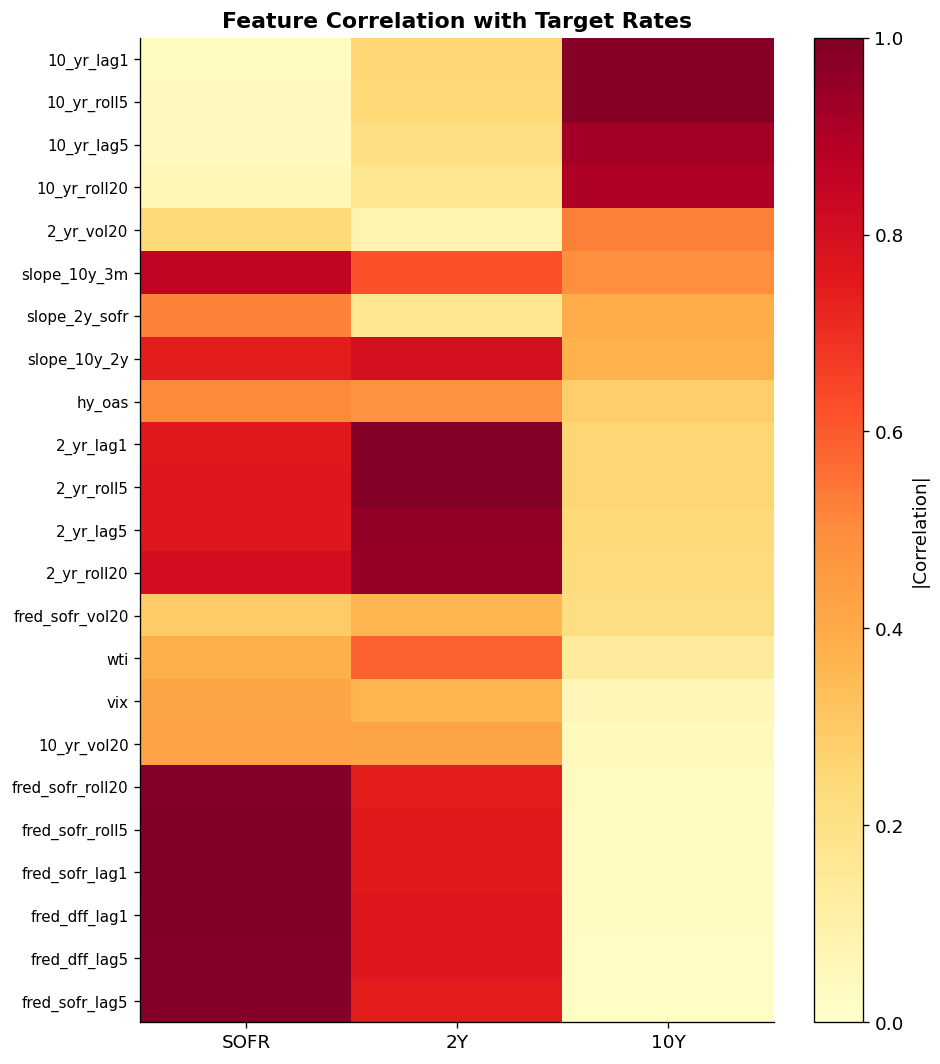

In [7]:
targets = {'SOFR': df['fred_sofr'], '2Y': df['2_yr'], '10Y': df['10_yr']}
corr = pd.DataFrame({name: feat.corrwith(series) for name, series in targets.items()})
corr = corr.abs().sort_values('10Y', ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
im = ax.imshow(corr.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(3));  ax.set_xticklabels(corr.columns)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=9)
plt.colorbar(im, ax=ax, label='|Correlation|')
ax.set_title('Feature Correlation with Target Rates', fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Save for use in notebook 03
TARGET_RATES = ['fred_sofr', '1_mo', '1_yr', '5_yr', '10_yr']
full = feat.join(df[TARGET_RATES]).dropna()
full.to_csv('../data/engineered_features.csv')
print(f"Saved: {full.shape[0]} rows × {full.shape[1]} columns → data/engineered_features.csv")
print(f"Target columns: {TARGET_RATES}")

Saved: 749 rows × 28 columns → data/engineered_features.csv
Target columns: ['fred_sofr', '1_mo', '1_yr', '5_yr', '10_yr']
